# Fake News Detection

### By Tejashri Pilla & Deepajothi S K (ML C72)

## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [1]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 9.4 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 9.8 MB/s eta 0:00:01
     ------------------ --------------------- 5.8/12.8 MB 9.8 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 9.7 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 9.7 MB/s eta 0:00:01
     ------------------------------------ --- 11.8/12.8 MB 9.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 9.2 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## Importing the necessary libraries

In [1]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [3]:
## Change the display properties of pandas to max
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [4]:
# Import the first file - True.csv
true_df = pd.read_csv("True.csv")
# Import the second file - Fake.csv
fake_df = pd.read_csv("Fake.csv")

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [5]:
# Inspect the DataFrame with True News to understand the given data
true_df.head()

,title,text,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017"


In [6]:
# Inspect the DataFrame with Fake News to understand the given data
fake_df.head()

,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...","December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...","December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,"December 25, 2017"


In [7]:
# Print the column details for True News DataFrame
print("Columns name in True News Dataframe:", true_df.columns.tolist())
print("-"*70)
true_df.info()
print("-"*70)
true_df.describe()

Columns name in True News Dataframe: ['title', 'text', 'date']
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB
----------------------------------------------------------------------


,title,text,date
count,21417,21417,21417
unique,20826,21192,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,"December 20, 2017"
freq,14,8,182


In [8]:
# Print the column details for Fake News Dataframe
print("Columns name in Fake News Dataframe:", fake_df.columns.tolist())
print("-"*70)
fake_df.info()
print("-"*70)
fake_df.describe()

Columns name in Fake News Dataframe: ['title', 'text', 'date']
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB
----------------------------------------------------------------------


,title,text,date
count,23502,23502,23481
unique,17914,17466,1692
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,"May 10, 2017"
freq,6,626,46


In [9]:
# Print the column names of both DataFrames
print("Columns name in True News Dataframe:", true_df.columns.tolist())
print("Columns name in Fake News Dataframe:", fake_df.columns.tolist())

Columns name in True News Dataframe: ['title', 'text', 'date']
Columns name in Fake News Dataframe: ['title', 'text', 'date']


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [10]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
true_df['news_label'] = 1
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
fake_df['news_label'] = 0

In [11]:
#Checking both the dataframes one by one
true_df.head()

,title,text,date,news_label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017",1


In [12]:
fake_df.head()

,title,text,date,news_label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...","December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...","December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,"December 25, 2017",0


### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [13]:
# Combine the true and fake news DataFrames into a single DataFrame
news_df = pd.concat([true_df, fake_df], axis=0)

In [14]:
# Display the first 5 rows of the combined DataFrame to verify the result
news_df.head()

,title,text,date,news_label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017",1


In [15]:
news_df.shape

(44940, 4)

In [16]:
# confirming if both the data sets are merged properly
news_df["news_label"].value_counts()

news_label
0    23523
1    21417
Name: count, dtype: int64

### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [17]:
# Check Presence of Null Values
news_df.isnull().sum()

title         21
text          21
date          42
news_label     0
dtype: int64

In [18]:
null_percentage = (news_df.isnull().sum() / len(news_df)) * 100
print(null_percentage)

title         0.046729
text          0.046729
date          0.093458
news_label    0.000000
dtype: float64


> <span style="color: blue;">As we can see that there are **21** null values in title, text and **42** null values in date.
> 
> <span style="color: blue;">These null values are **less than 0.1%** of total data.
> 
> <span style="color: blue;">Hence, we can remove these nulls as they don't provide any useful information to us.</span>

In [19]:
# Handle Rows with Null Values
news_df = news_df.dropna()
news_df.isnull().sum()

title         0
text          0
date          0
news_label    0
dtype: int64

### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [20]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
news_df['news_text'] = news_df['title'].astype(str) + ' ' + news_df['text'].astype(str)

# Drop the irrelevant columns from the DataFrame as they are no longer needed
news_df=news_df.drop(['title','date', 'text'], axis = 1)

# Display the first 5 rows of the updated DataFrame to check the result
news_df.head()

,news_label,news_text
0,1,"As U.S. budget fight looms, Republicans flip t..."
1,1,U.S. military to accept transgender recruits o...
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,1,FBI Russia probe helped by Australian diplomat...
4,1,Trump wants Postal Service to charge 'much mor...


## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [21]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
# Lets suffle the dataset so that it should not create any probelems in training
df_clean = pd.DataFrame()

# Add 'news_label' column to the new dataframe for topic identification
df_clean['news_label'] = news_df['news_label']

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [22]:
# Write the function here to clean the text and remove all the unnecessary elements
def text_cleanup(text):
    # Convert to lower case
    text = text.lower()
    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove words with numbers
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    return text

#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [23]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
df_clean['cleaned_text'] = news_df['news_text'].apply(text_cleanup)

In [24]:
df_clean.head()

,news_label,cleaned_text
0,1,as us budget fight looms republicans flip thei...
1,1,us military to accept transgender recruits on ...
2,1,senior us republican senator let mr mueller do...
3,1,fbi russia probe helped by australian diplomat...
4,1,trump wants postal service to charge much more...


### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [25]:
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('english')) # removing english stop words
lemmatizer = WordNetLemmatizer() # doing lemmatization to keep single word variable

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags
def lemmatize_nouns(text):
    # Tokenize and POS tag
    tokens = word_tokenize(text)  # Tekenizing works
    tagged = pos_tag(tokens)  #Doing POS tagging 
    
    # Keeping only NN and NNS, filtered stopwords and lemmatized words
    lemmas = []
    for word, tag in tagged:
        if tag in ('NN', 'NNS') and word not in stop_words:
            lemmas.append(lemmatizer.lemmatize(word, pos='n'))
    
    return lemmas

#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [27]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
df_clean['lemmatized_text'] = df_clean['cleaned_text'].apply(lemmatize_nouns)

In [28]:
df_clean.head()

,news_label,cleaned_text,lemmatized_text
0,1,as us budget fight looms republicans flip thei...,"[budget, fight, republican, script, washington..."
1,1,us military to accept transgender recruits on ...,"[transgender, recruit, monday, washington, reu..."
2,1,senior us republican senator let mr mueller do...,"[senator, job, washington, counsel, investigat..."
3,1,fbi russia probe helped by australian diplomat...,"[fbi, russia, probe, diplomat, tipoff, washing..."
4,1,trump wants postal service to charge much more...,"[trump, service, amazon, shipment, reuters, pr..."


In [29]:
# Lets suffle the dataset so that it does not create probelems in training
df_clean = df_clean.sample(frac = 1, random_state=42).reset_index(drop=True)

In [30]:
df_clean.head()

,news_label,cleaned_text,lemmatized_text
0,0,breaking gop chairman grassley has had enough...,"[gop, chairman, grassley, demand, testimony, d..."
1,0,failed gop candidates remembered in hilarious...,"[gop, candidate, eulogy, donald, trump, gop, t..."
2,0,mike pences new dc neighbors are hilariously ...,"[mike, pences, neighbor, homophobic, bigot, mi..."
3,1,california ag pledges to defend birth control ...,"[california, ag, pledge, birth, control, insur..."
4,0,az ranchers living on usmexico border destroy ...,"[az, rancher, border, destroy, nancy, pelosis,..."


In [31]:
df_clean.shape

(44898, 3)

### Save the Cleaned data as a csv file (Recommended)

In [32]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)

In [2]:
df_clean = pd.read_csv("clean_df.csv")

In [3]:
# Check the first few rows of the DataFrame
df_clean.head()

,news_label,cleaned_text,lemmatized_text
0,0,breaking gop chairman grassley has had enough...,"['gop', 'chairman', 'grassley', 'demand', 'tes..."
1,0,failed gop candidates remembered in hilarious...,"['gop', 'candidate', 'eulogy', 'donald', 'trum..."
2,0,mike pences new dc neighbors are hilariously ...,"['mike', 'pences', 'neighbor', 'homophobic', '..."
3,1,california ag pledges to defend birth control ...,"['california', 'ag', 'pledge', 'birth', 'contr..."
4,0,az ranchers living on usmexico border destroy ...,"['az', 'rancher', 'border', 'destroy', 'nancy'..."


In [4]:
# Check the dimensions of the DataFrame
df_clean.shape

(44898, 3)

In [5]:
# Check the number of non-null entries and data types of each column
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   news_label       44898 non-null  int64 
 1   cleaned_text     44898 non-null  object
 2   lemmatized_text  44898 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [6]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
from sklearn.model_selection import train_test_split

X = df_clean[['cleaned_text','lemmatized_text']]
y = df_clean['news_label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
# Combine features and labels for training and validation set to get train_df and val_df

train_df = X_train.copy()
train_df['news_label'] = y_train.values

val_df = X_val.copy()
val_df['news_label'] = y_val.values

In [8]:
train_df.shape

(31428, 3)

In [9]:
train_df.head()

,cleaned_text,lemmatized_text,news_label
13970,awesome attorney general jeff sessions just dr...,"['attorney', 'jeff', 'session', 'doj', 'swamp'...",0
41668,official no formal secret service discussions ...,"['service', 'discussion', 'trump', 'camp', 're...",1
26810,conservatives get out measuring tape find oba...,"['conservative', 'tape', 'house', 'sort', 'cen...",0
30967,house senate conservative republicans plan own...,"['house', 'senate', 'repeal', 'bill', 'reuters...",1
26072,busted trumps pick for top usda scientist is ...,"['trump', 'pick', 'scientist', 'scientist', 'e...",0


In [10]:
val_df.shape

(13470, 3)

In [11]:
val_df.head()

,cleaned_text,lemmatized_text,news_label
22216,tillerson trump did not discuss sources method...,"['tillerson', 'trump', 'source', 'method', 'ru...",1
27917,students find fck nrs scrawled on classroom d...,"['student', 'classroom', 'door', 'trump', 'hat...",0
25007,watch van jones says exactly what needs to be...,"['watch', 'van', 'jones', 'tonight', 'election...",0
1377,republican national committee cuts ties with m...,"['committee', 'cut', 'tie', 'moore', 'politico...",1
32476,the plans for the republican convention just ...,"['plan', 'convention', 'blow', 'plan', 'conven...",0


## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [12]:
# Add a new column to calculate the character length of cleaned news text
train_df['cleaned_text_len'] = train_df['cleaned_text'].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
train_df['lemmatized_text_len'] = train_df['lemmatized_text'].str.len()

In [13]:
train_df.head()

,cleaned_text,lemmatized_text,news_label,cleaned_text_len,lemmatized_text_len
13970,awesome attorney general jeff sessions just dr...,"['attorney', 'jeff', 'session', 'doj', 'swamp'...",0,1461,868
41668,official no formal secret service discussions ...,"['service', 'discussion', 'trump', 'camp', 're...",1,1641,840
26810,conservatives get out measuring tape find oba...,"['conservative', 'tape', 'house', 'sort', 'cen...",0,3224,1580
30967,house senate conservative republicans plan own...,"['house', 'senate', 'repeal', 'bill', 'reuters...",1,486,272
26072,busted trumps pick for top usda scientist is ...,"['trump', 'pick', 'scientist', 'scientist', 'e...",0,2281,1238


##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

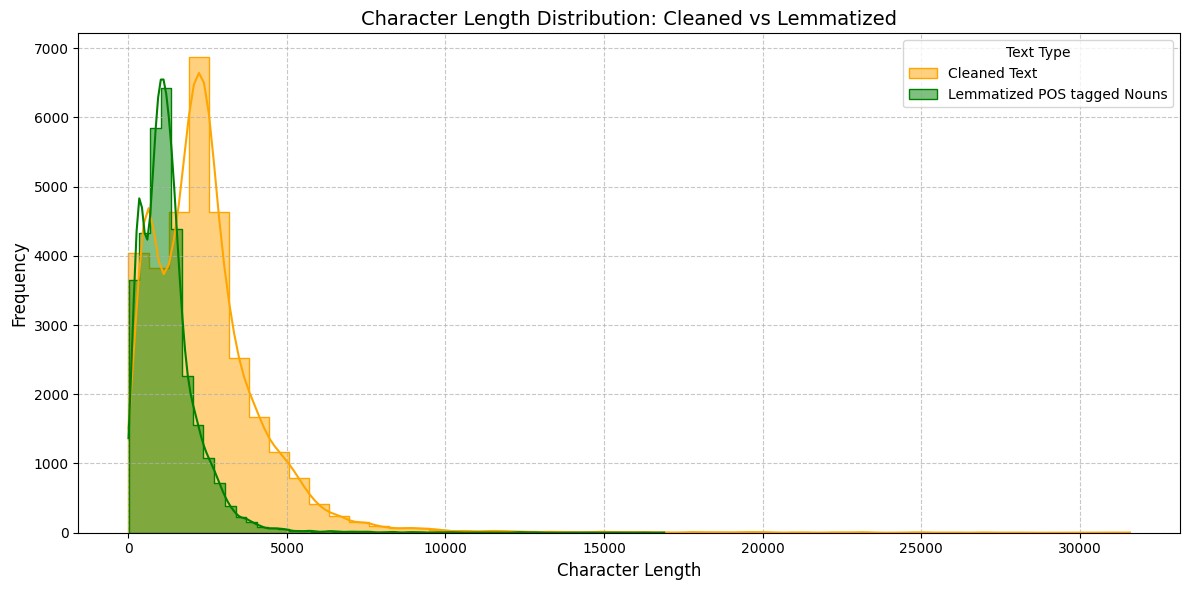

In [14]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(12, 6))
# Add histogram for cleaned news text
sns.histplot(train_df['cleaned_text_len'], color='orange', label='Cleaned Text', kde=True, bins=50, alpha=0.5, element="step")
# Add histogram for lemmatized news text with POS tags removed
sns.histplot(train_df['lemmatized_text_len'], color='green', label='Lemmatized POS tagged Nouns', kde=True, bins=50, alpha=0.5, element="step")

plt.title('Character Length Distribution: Cleaned vs Lemmatized', fontsize=14)
plt.xlabel('Character Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title="Text Type")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

{"state'": 1.0, "year'": 0.8997041420118344, "government'": 0.8794871794871795, "trump'": 0.6670611439842209, "country'": 0.6567061143984221, "people'": 0.642603550295858, "week'": 0.5701183431952662, "month'": 0.5142998027613412, "time'": 0.49072978303747533, "official'": 0.4383629191321499, "group'": 0.41834319526627217, "statement'": 0.41272189349112426, "day'": 0.3745562130177515, "issue'": 0.3259368836291913, "monday'": 0.32189349112426036, "tuesday'": 0.3193293885601578, "wednesday'": 0.3108481262327416, "leader'": 0.29743589743589743, "part'": 0.29428007889546354, "party'": 0.2903353057199211, "plan'": 0.28826429980276136, "policy'": 0.28727810650887575, "thursday'": 0.28717948717948716, "friday'": 0.2865877712031558, "law'": 0.2857001972386588, "way'": 0.2819526627218935, "support'": 0.2700197238658777, "election'": 0.2686390532544379, "washington'": 0.26844181459566074, "company'": 0.2556213017751479, "decision'": 0.2546351084812623, "effort'": 0.24497041420118343, "lawmaker'"

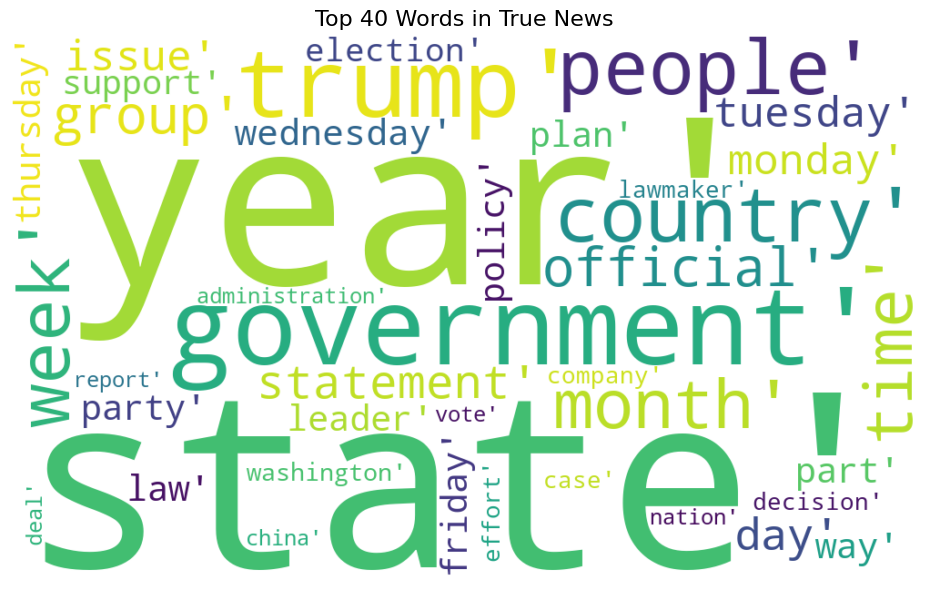

In [15]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
from wordcloud import WordCloud

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
train_true_df = train_df[train_df['news_label'] == 1].copy()
all_text = ' '.join(train_true_df['lemmatized_text'])

# Generate word cloud for True News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in True News", fontsize=16)
plt.tight_layout()
plt.show() 

##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

{"trump'": 1.0, "people'": 0.827922077922078, "time'": 0.6097132034632035, "year'": 0.5205627705627706, "president'": 0.505073051948052, "state'": 0.4559659090909091, "way'": 0.3963744588744589, "clinton'": 0.3713474025974026, "medium'": 0.35436958874458874, "country'": 0.3529491341991342, "thing'": 0.330762987012987, "woman'": 0.3196022727272727, "day'": 0.31757305194805197, "fact'": 0.2929518398268398, "government'": 0.29078733766233766, "news'": 0.27306547619047616, "video'": 0.2710362554112554, "house'": 0.2701569264069264, "man'": 0.2629193722943723, "week'": 0.2390422077922078, "america'": 0.23451028138528138, "party'": 0.22903138528138528, "report'": 0.2242965367965368, "group'": 0.22409361471861472, "obama'": 0.21820887445887446, "part'": 0.21387987012987014, "case'": 0.21259469696969696, "statement'": 0.21144480519480519, "world'": 0.20840097402597402, "donald' trump'": 0.20589826839826839, "american'": 0.20522186147186147, "family'": 0.20204274891774893, "today'": 0.193655303

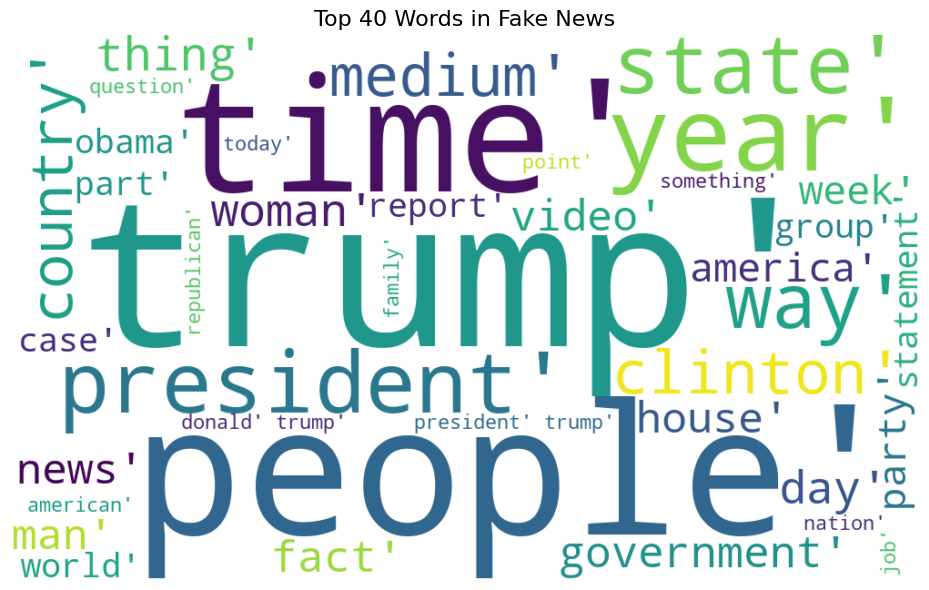

In [16]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
train_fake_df = train_df[train_df['news_label'] == 0].copy()
all_text = ' '.join(train_fake_df['lemmatized_text'])

# Generate word cloud for Fake News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in Fake News", fontsize=16)
plt.tight_layout()
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [17]:
# Write a function to get the specified top n-grams
true_news = train_df[train_df['news_label'] == 1]['lemmatized_text']
fake_news = train_df[train_df['news_label'] == 0]['lemmatized_text']

def plot_top_ngrams(corpus, ngram_range=(1,1), top_n=20, title='', color='skyblue'):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    ngram_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)[:top_n]
    print("ngram_freq: ",ngram_freq)
    # Convert to DataFrame for easy plotting
    df_ngram = pd.DataFrame(ngram_freq, columns=['n-gram', 'frequency'])
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(df_ngram['n-gram'][::-1], df_ngram['frequency'][::-1], color=color)
    plt.title(title, fontsize=14)
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

true_corpus = true_news.tolist()
fake_corpus = fake_news.tolist()

##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [18]:
# Handle NaN values in the text data
nan_percent = train_df['cleaned_text'].isna().mean() * 100
print(f"Missing text: {nan_percent:.2f}%")

Missing text: 0.00%


> <span style="color: blue;">There are no NaN values present in train dataframe as we have already handled them earlier.</span>

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

ngram_freq:  [('trump', 31848), ('state', 25643), ('president', 19272), ('reuters', 16509), ('government', 13804), ('year', 13168), ('house', 12810), ('people', 10800), ('party', 10443), ('election', 10072)]


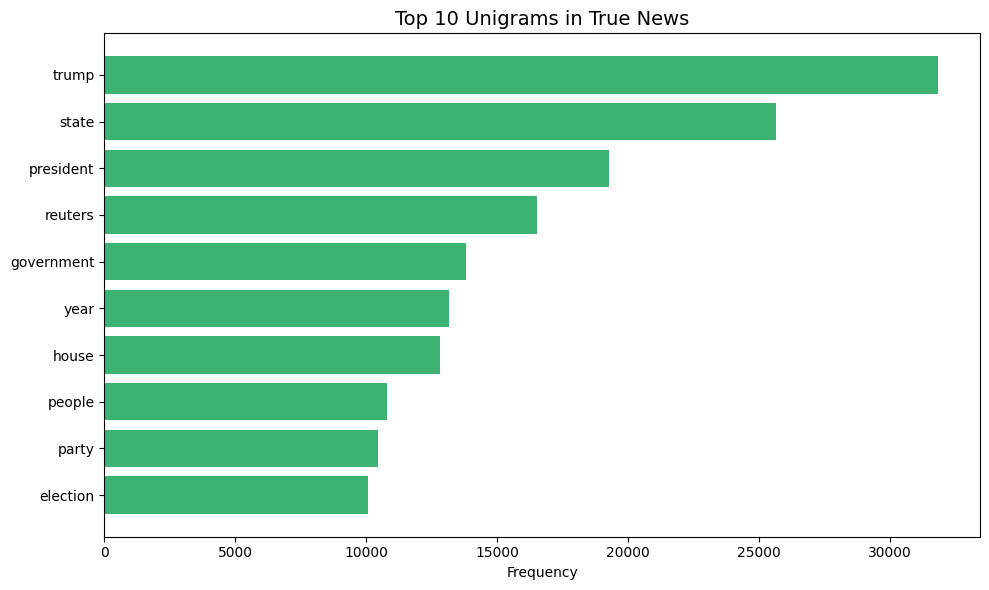

In [19]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams(true_corpus, (1,1), 10, "Top 10 Unigrams in True News", 'mediumseagreen')

##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



ngram_freq:  [('donald trump', 2243), ('washington reuters', 1934), ('president trump', 1932), ('president barack', 1924), ('president donald', 1877), ('reuters president', 1857), ('secretary state', 1652), ('house representative', 1585), ('state department', 1403), ('trump campaign', 1369)]


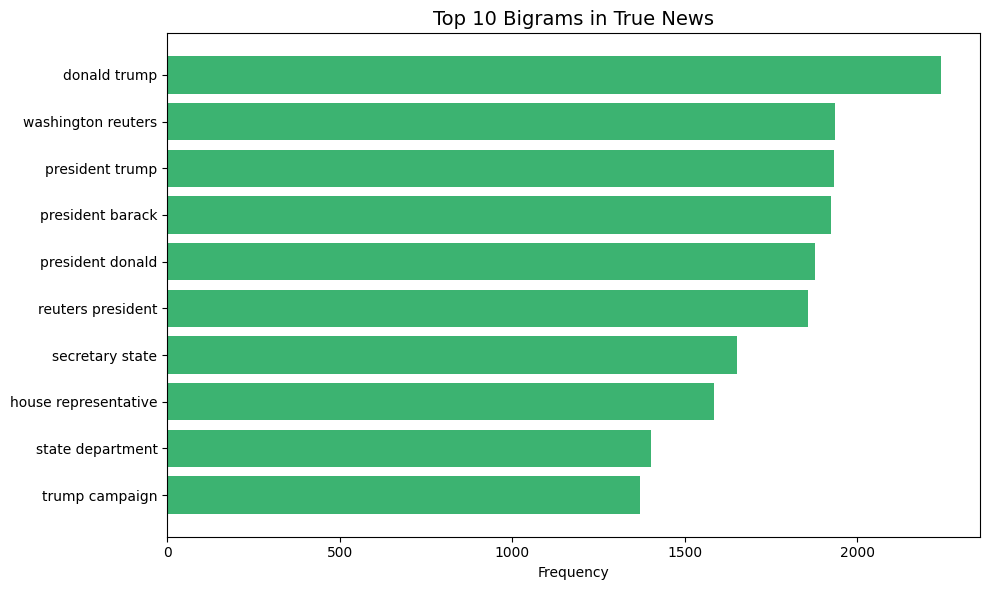

In [20]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams(true_corpus, (2,2), 10, "Top 10 Bigrams in True News", 'mediumseagreen')

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



ngram_freq:  [('president barack obama', 1113), ('president donald trump', 928), ('reuters president trump', 639), ('washington reuters president', 566), ('secretary state rex', 477), ('president vladimir putin', 451), ('state rex tillerson', 448), ('speaker paul ryan', 360), ('leader mitch mcconnell', 326), ('chancellor angela merkel', 314)]


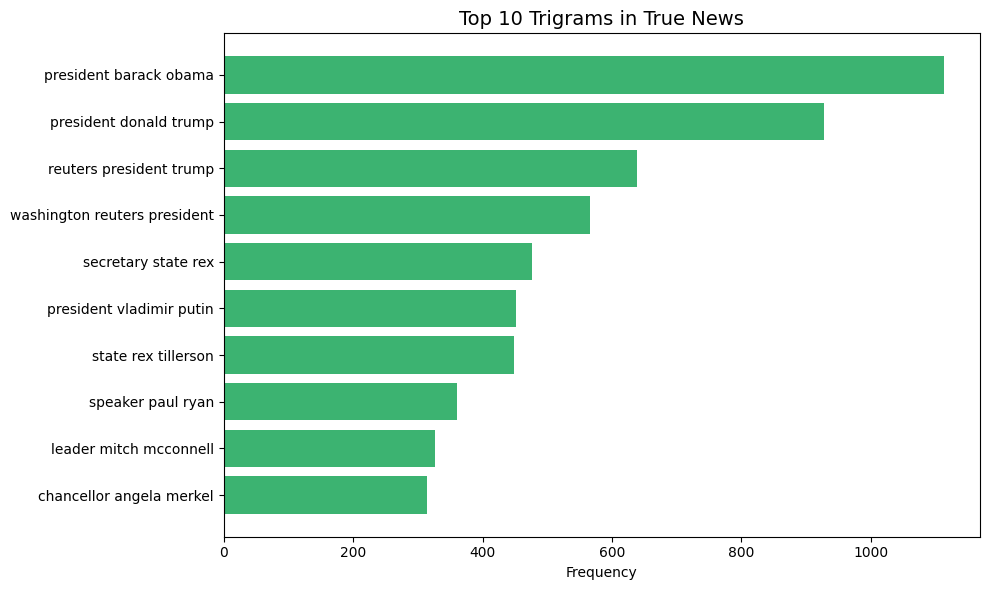

In [21]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams(true_corpus, (3,3), 10, "Top 10 Trigrams in True News", 'mediumseagreen')

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

ngram_freq:  [('trump', 46684), ('president', 18858), ('people', 18517), ('state', 15096), ('clinton', 12852), ('time', 12474), ('year', 10408), ('news', 10385), ('image', 9910), ('obama', 8523)]


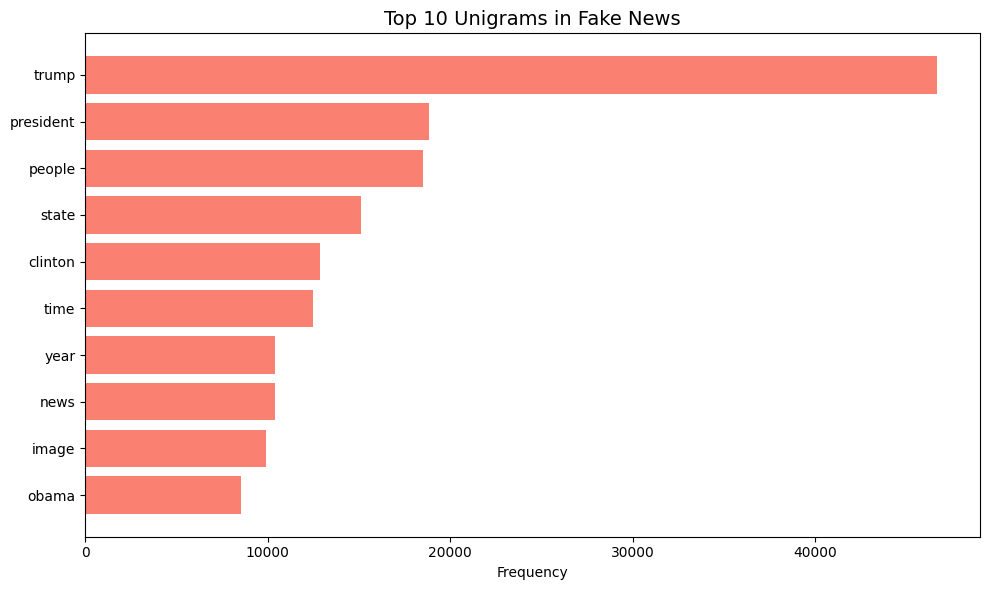

In [22]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams(fake_corpus, (1,1), 10, "Top 10 Unigrams in Fake News", 'salmon')

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



ngram_freq:  [('donald trump', 3668), ('president trump', 2790), ('president obama', 1866), ('trump campaign', 1442), ('trump supporter', 1348), ('century wire', 1333), ('barack obama', 1239), ('state department', 1124), ('secretary state', 1114), ('trump realdonaldtrump', 1096)]


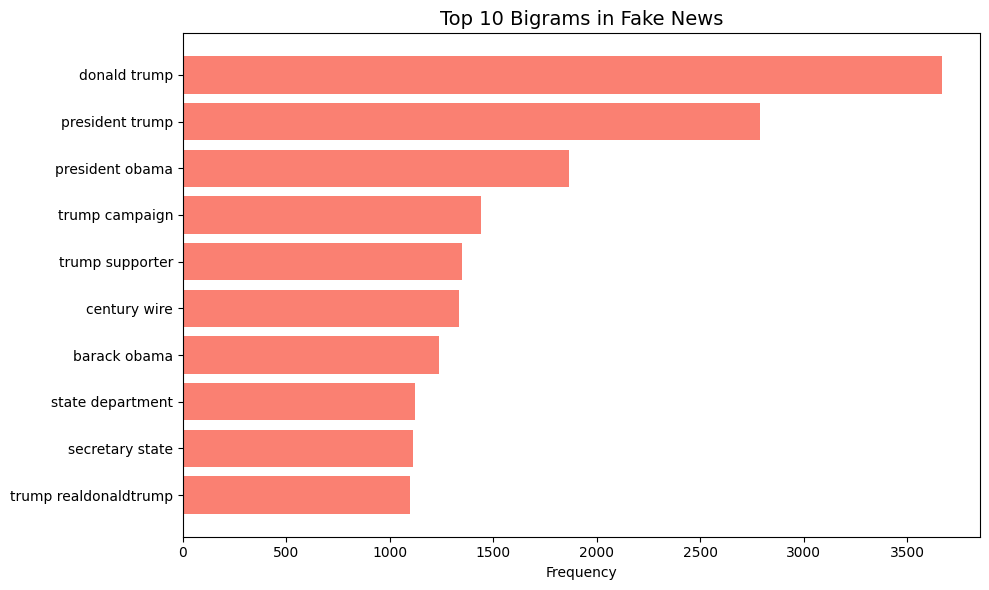

In [23]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams(fake_corpus, (2,2), 10, "Top 10 Bigrams in Fake News", 'salmon')

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



ngram_freq:  [('news century wire', 659), ('president barack obama', 540), ('donald trump realdonaldtrump', 504), ('image video screen', 416), ('video screen capture', 390), ('president donald trump', 208), ('department homeland security', 202), ('secretary state clinton', 180), ('image chip image', 177), ('house press secretary', 164)]


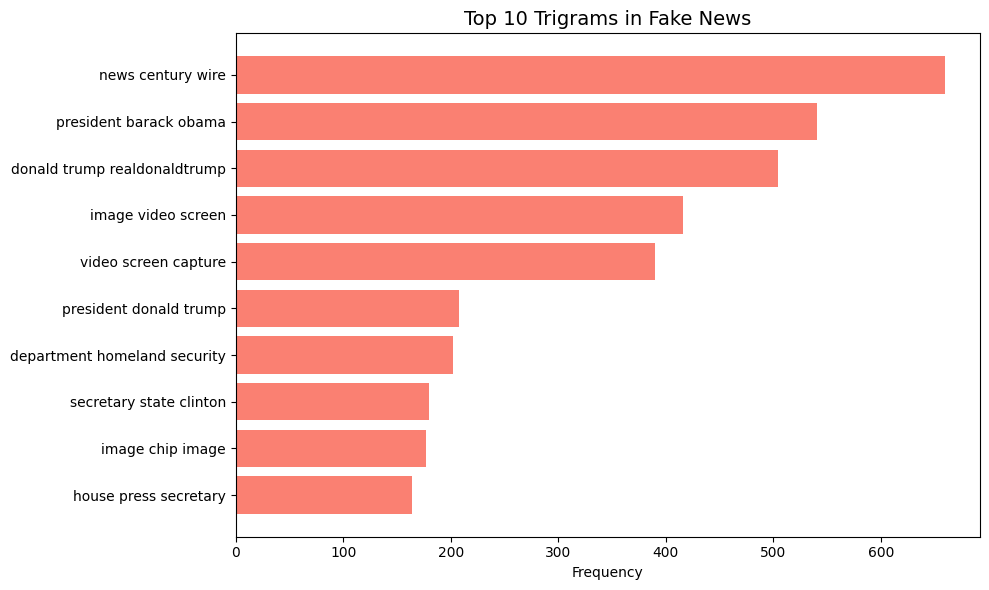

In [24]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams(fake_corpus, (3,3), 10, "Top 10 Trigrams in Fake News", 'salmon')

## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [25]:
# Add a new column to calculate the character length of cleaned news text
val_df['cleaned_text_len'] = val_df['cleaned_text'].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
val_df['lemmatized_text_len'] = val_df['lemmatized_text'].str.len()

In [26]:
val_df.head()

,cleaned_text,lemmatized_text,news_label,cleaned_text_len,lemmatized_text_len
22216,tillerson trump did not discuss sources method...,"['tillerson', 'trump', 'source', 'method', 'ru...",1,680,447
27917,students find fck nrs scrawled on classroom d...,"['student', 'classroom', 'door', 'trump', 'hat...",0,2273,771
25007,watch van jones says exactly what needs to be...,"['watch', 'van', 'jones', 'tonight', 'election...",0,1150,523
1377,republican national committee cuts ties with m...,"['committee', 'cut', 'tie', 'moore', 'politico...",1,536,278
32476,the plans for the republican convention just ...,"['plan', 'convention', 'blow', 'plan', 'conven...",0,2332,947


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

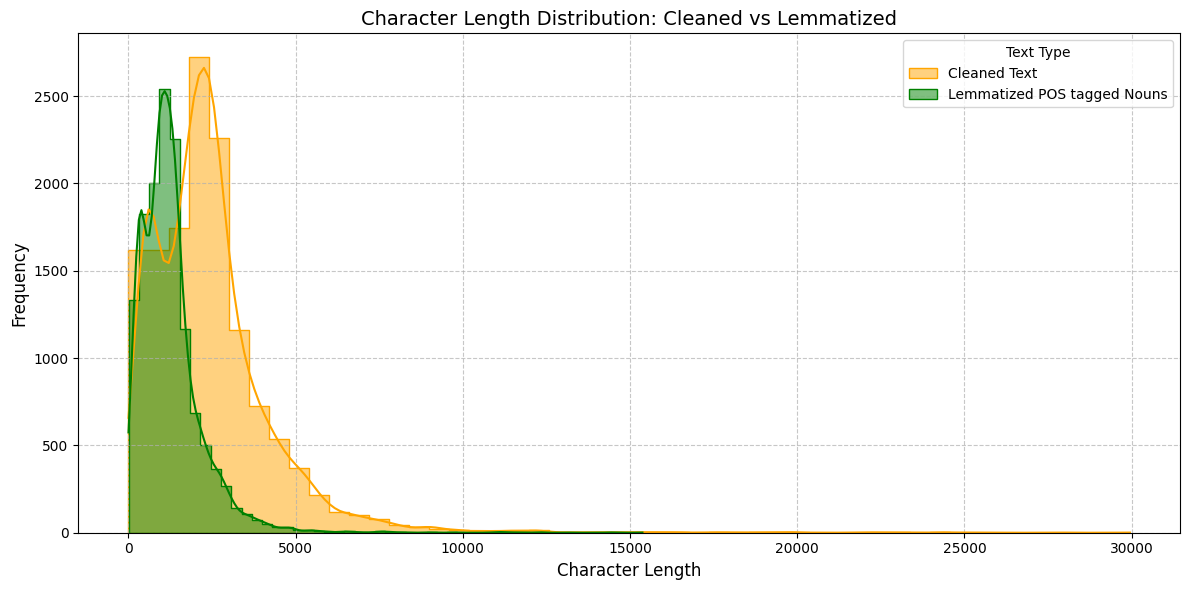

In [27]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(12, 6))
# Add histogram for cleaned news text
sns.histplot(val_df['cleaned_text_len'], color='orange', label='Cleaned Text', kde=True, bins=50, alpha=0.5, element="step")
# Add histogram for lemmatized news text with POS tags removed
sns.histplot(val_df['lemmatized_text_len'], color='green', label='Lemmatized POS tagged Nouns', kde=True, bins=50, alpha=0.5, element="step")

plt.title('Character Length Distribution: Cleaned vs Lemmatized', fontsize=14)
plt.xlabel('Character Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title="Text Type")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

{"state'": 1.0, "trump'": 0.935251798561151, "government'": 0.7776324395029431, "year'": 0.775343361674297, "people'": 0.6102027468933944, "country'": 0.5739045127534336, "week'": 0.474329627207325, "time'": 0.40827338129496404, "month'": 0.4017331589274035, "official'": 0.39633747547416615, "group'": 0.381458469587966, "party'": 0.35284499672988884, "statement'": 0.34646827992151735, "president'": 0.32047089601046436, "law'": 0.2969260954872466, "day'": 0.29300196206671025, "election'": 0.28106605624591235, "tuesday'": 0.276324395029431, "monday'": 0.2681491170699804, "leader'": 0.2666775670372793, "issue'": 0.26258992805755393, "reuters'": 0.25882930019620665, "wednesday'": 0.24525833878351863, "policy'": 0.24280575539568344, "house'": 0.24133420536298233, "company'": 0.23839110529758012, "thursday'": 0.2354480052321779, "administration'": 0.2352844996729889, "part'": 0.23381294964028776, "campaign'": 0.23201438848920863, "plan'": 0.23005232177894047, "support'": 0.22972531066056245,

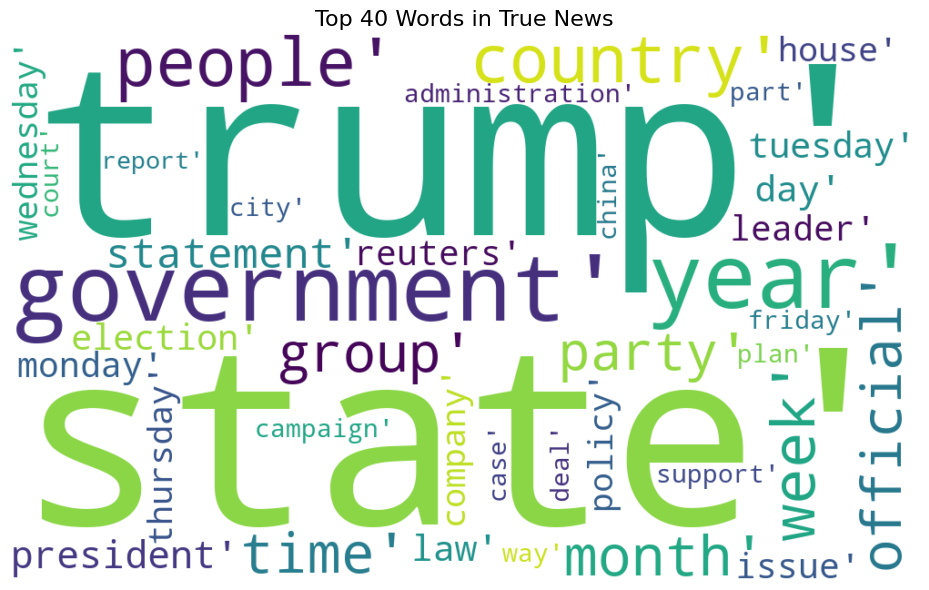

In [28]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text
# Filter news with label 1 (True News) and convert to it string and handle any non-string values
val_true_df = val_df[val_df['news_label'] == 1].copy()
all_text = ' '.join(val_true_df['lemmatized_text'])

# Generate word cloud for True News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in True News", fontsize=16)
plt.tight_layout()
plt.show()

##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

{"trump'": 1.0, "people'": 0.598314606741573, "time'": 0.38657497094149557, "president'": 0.3858000774893452, "year'": 0.34172801239829526, "state'": 0.3377566834560248, "clinton'": 0.2926191398682681, "country'": 0.25048430840759395, "way'": 0.24825648973266176, "day'": 0.22626888802789616, "woman'": 0.22355676094537, "house'": 0.22181325067803176, "medium'": 0.21997287872917473, "video'": 0.21125532739248354, "thing'": 0.21106160402944596, "government'": 0.20457187136768695, "news'": 0.19469197985277023, "fact'": 0.18984889577683067, "man'": 0.17493219682293684, "obama'": 0.17396358000774895, "america'": 0.17347927160015497, "campaign'": 0.17289810151104223, "group'": 0.17028283611003486, "report'": 0.16398682681131344, "week'": 0.162340178225494, "party'": 0.16079039132119333, "american'": 0.14897326617590081, "case'": 0.144711352189074, "republican'": 0.14393645873692368, "world'": 0.14277411855869818, "democrat'": 0.138221619527315, "part'": 0.1380278961642774, "something'": 0.137

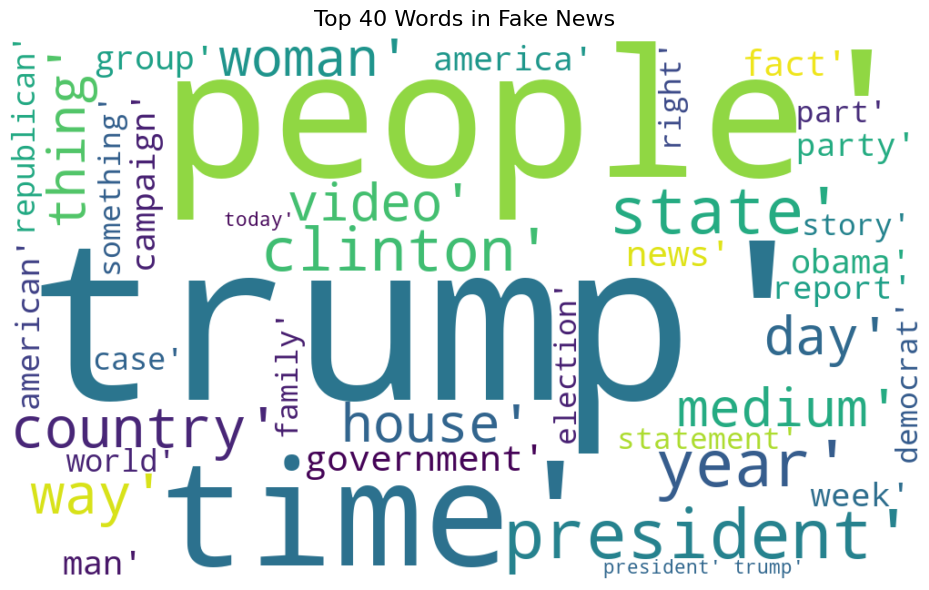

In [29]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text
# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
val_fake_df = val_df[val_df['news_label'] == 0].copy()
all_text = ' '.join(val_fake_df['lemmatized_text'])

# Generate word cloud for Fake News
wordcloud = WordCloud(width=1000, height=600,
                      background_color='white',
                      max_words=40,
                      colormap='viridis').generate(all_text)
print(wordcloud.words_)
# Display the WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 Words in Fake News", fontsize=16)
plt.tight_layout()
plt.show()

### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [30]:
## Write a function to get the specified top n-grams
true_news = val_df[val_df['news_label'] == 1]['lemmatized_text']
fake_news = val_df[val_df['news_label'] == 0]['lemmatized_text']

# Function to get the specified top n-grams is already defined in section 4.3.1

true_corpus = true_news.tolist()
fake_corpus = fake_news.tolist()

##### 5.3.2 Handle the NaN values

In [31]:
## First handle NaN values in the text data
nan_percent = val_df['cleaned_text'].isna().mean() * 100
print(f"Missing text: {nan_percent:.2f}%")

Missing text: 0.00%


> <span style="color: blue;">There are no NaN values present in validation dataframe as we have already handled them earlier.</span>

### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

ngram_freq:  [('trump', 13843), ('state', 10705), ('president', 8216), ('reuters', 7261), ('government', 6075), ('year', 5799), ('house', 5570), ('people', 4624), ('party', 4513), ('election', 4464)]


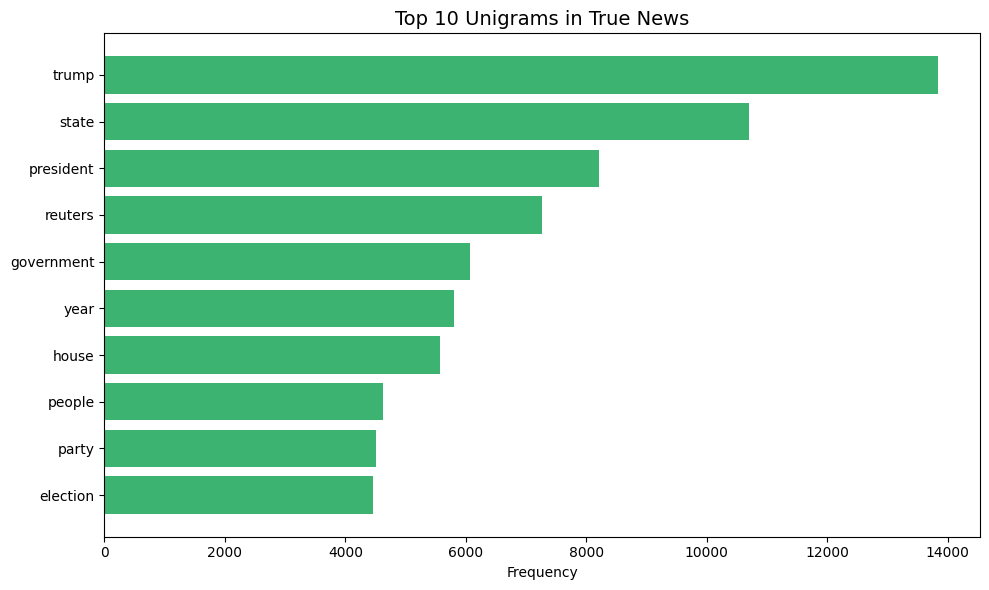

In [32]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams(true_corpus, (1,1), 10, "Top 10 Unigrams in True News", 'mediumseagreen')

##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

ngram_freq:  [('donald trump', 1012), ('president trump', 880), ('president barack', 856), ('washington reuters', 842), ('president donald', 784), ('reuters president', 772), ('secretary state', 697), ('house representative', 691), ('trump campaign', 586), ('barack obama', 585)]


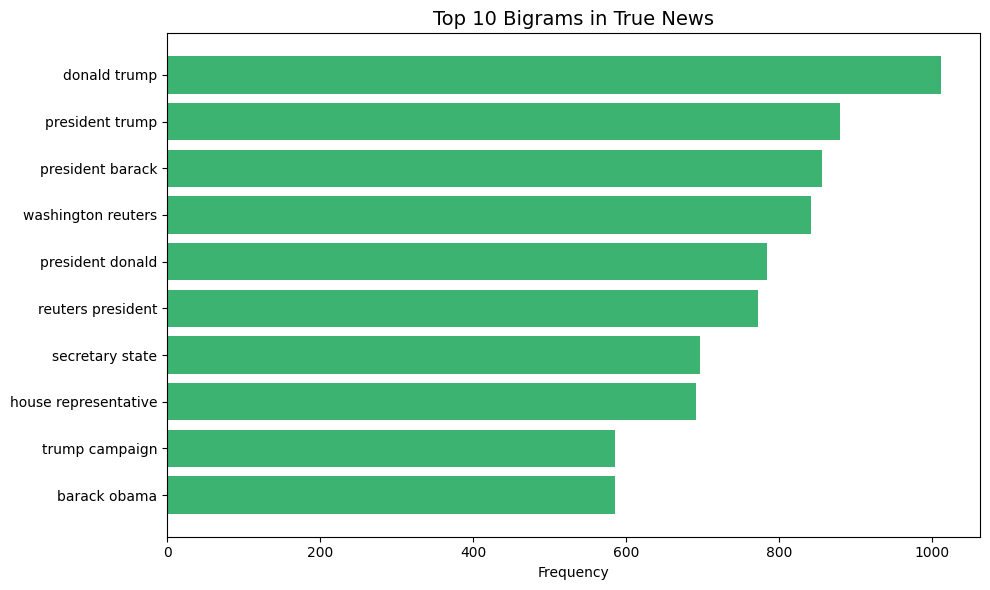

In [33]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams(true_corpus, (2,2), 10, "Top 10 Bigrams in True News", 'mediumseagreen')

##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

ngram_freq:  [('president barack obama', 503), ('president donald trump', 422), ('reuters president trump', 284), ('washington reuters president', 236), ('secretary state rex', 195), ('president vladimir putin', 193), ('state rex tillerson', 187), ('leader mitch mcconnell', 155), ('chancellor angela merkel', 147), ('speaker paul ryan', 147)]


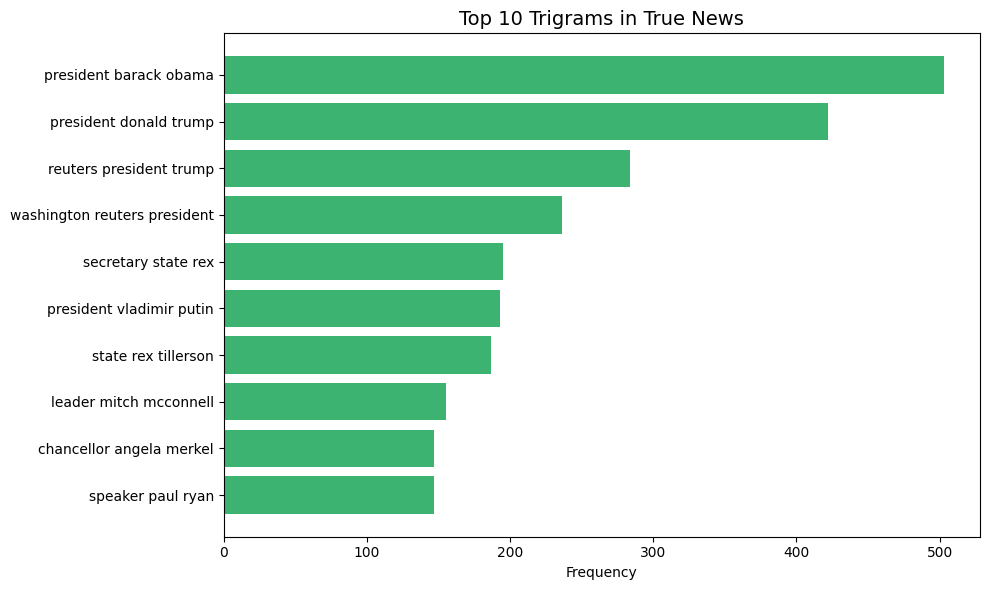

In [34]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams(true_corpus, (3,3), 10, "Top 10 Trigrams in True News", 'mediumseagreen')

### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

ngram_freq:  [('trump', 20214), ('president', 8114), ('people', 7841), ('state', 6322), ('clinton', 5348), ('time', 5256), ('year', 4452), ('news', 4287), ('image', 4123), ('obama', 3506)]


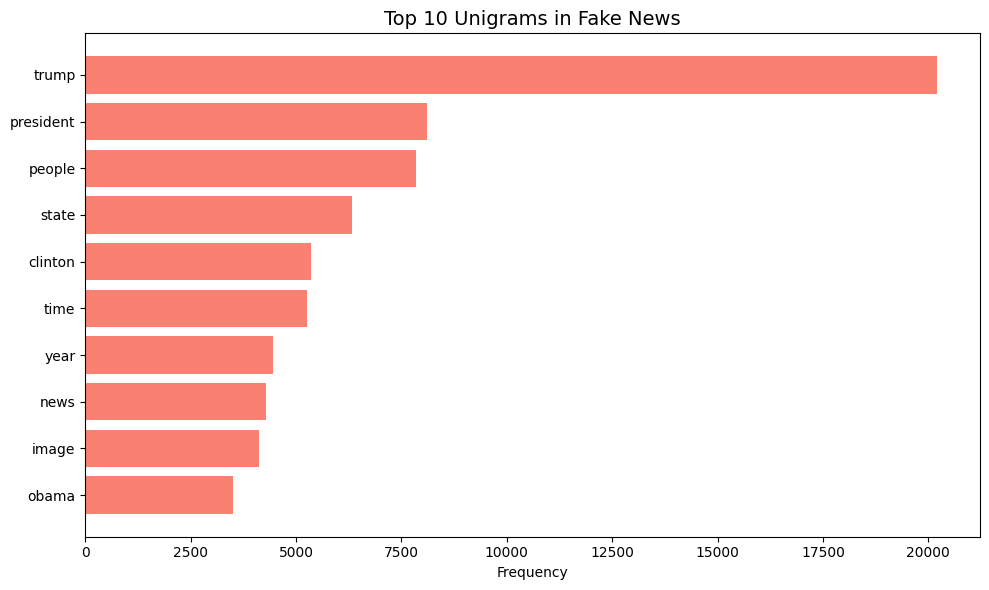

In [35]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams(fake_corpus, (1,1), 10, "Top 10 Unigrams in Fake News", 'salmon')

##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

ngram_freq:  [('donald trump', 1585), ('president trump', 1325), ('president obama', 744), ('trump campaign', 565), ('century wire', 551), ('trump supporter', 528), ('barack obama', 512), ('law enforcement', 468), ('police officer', 466), ('secretary state', 461)]


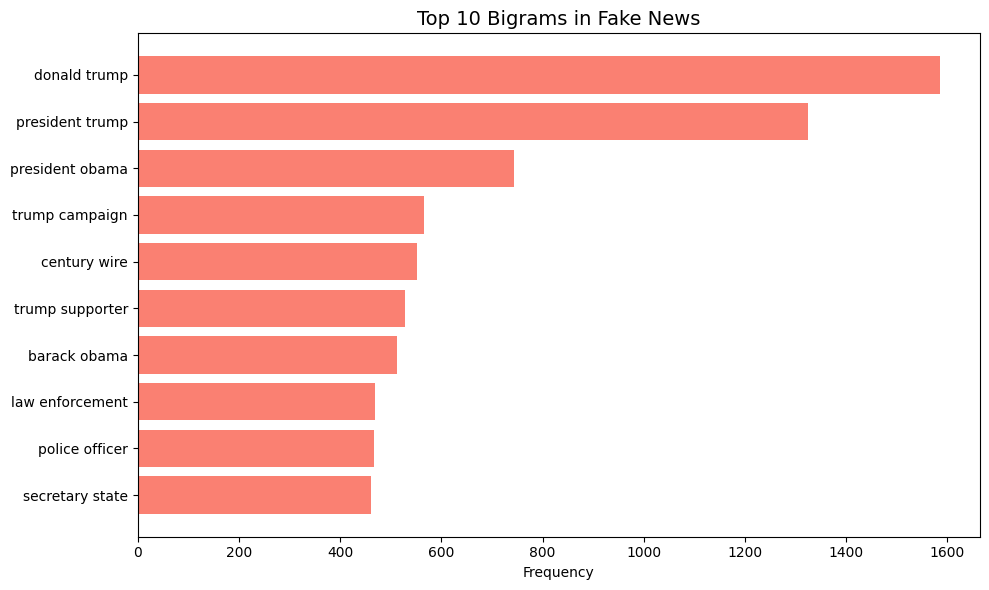

In [36]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams(fake_corpus, (2,2), 10, "Top 10 Bigrams in Fake News", 'salmon')

##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

ngram_freq:  [('news century wire', 274), ('donald trump realdonaldtrump', 234), ('president barack obama', 198), ('image video screen', 182), ('video screen capture', 173), ('president donald trump', 108), ('department homeland security', 92), ('image chip image', 79), ('house press secretary', 79), ('fbi director james', 74)]


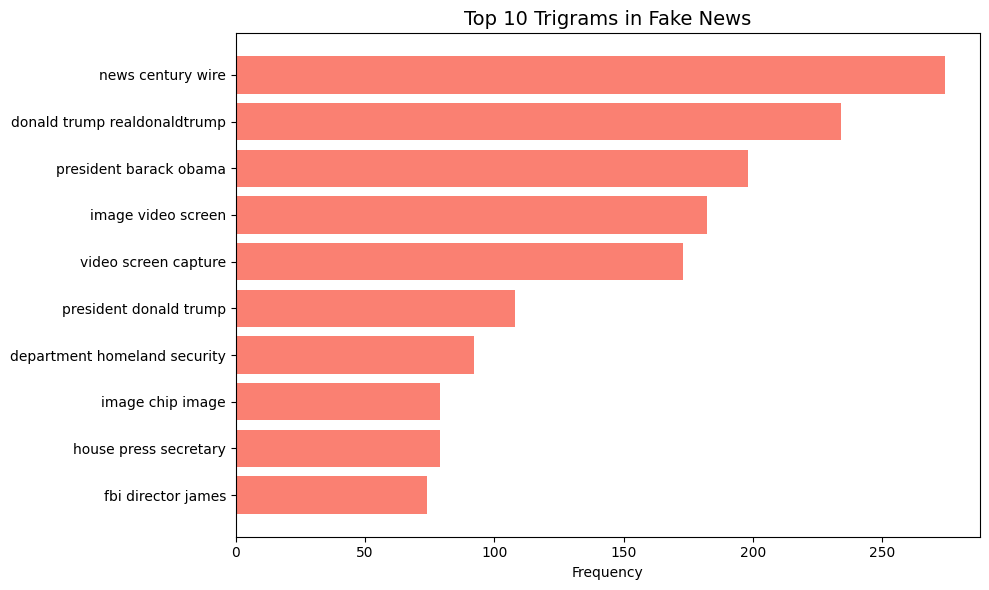

In [37]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams(fake_corpus, (3,3), 10, "Top 10 Trigrams in Fake News", 'salmon')

## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [38]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
import gensim.downloader as api
w2v_model = api.load('word2vec-google-news-300')

### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [39]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data
def get_doc_vector(tokens, model):
    vectors = [model[word] for word in tokens if word in model]
    if not vectors:
        return np.zeros(model.vector_size, dtype=float)
    return np.mean(vectors, axis=0)

X_train_vector = np.vstack(X_train["lemmatized_text"].apply(lambda x: get_doc_vector(x, w2v_model)))
X_val_vector = np.vstack(X_val["lemmatized_text"].apply(lambda x: get_doc_vector(x, w2v_model)))

## Extract the target variable for the training data and validation data

print("X_train_vec shape:", X_train_vector.shape)  
print("X_val_vec shape:",   X_val_vector.shape)     
print("y_train shape:",     y_train.shape)      
print("y_val shape:",       y_val.shape)  

X_train_vec shape: (31428, 300)
X_val_vec shape: (13470, 300)
y_train shape: (31428,)
y_val shape: (13470,)


## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [41]:
## Initialise Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)
## Train Logistic Regression model on training data
lr.fit(X_train_vector,y_train)
## Predict on validation data
y_pred_lr = lr.predict(X_val_vector)

##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [42]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy_lr  = accuracy_score(y_val, y_pred_lr)
precision_lr = precision_score(y_val, y_pred_lr)
recall_lr    = recall_score(y_val, y_pred_lr)
f1_lr        = f1_score(y_val, y_pred_lr)

# 2. Print the scores
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Accuracy : 0.7034
Precision: 0.6981
Recall   : 0.6703
F1-Score : 0.6839


In [43]:
# Classification Report
print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      7022
           1       0.70      0.67      0.68      6448

    accuracy                           0.70     13470
   macro avg       0.70      0.70      0.70     13470
weighted avg       0.70      0.70      0.70     13470



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [44]:
## Initialise Decision Tree model
dt = DecisionTreeClassifier(
    criterion='gini',     
    max_depth=35,        
    min_samples_split=4,  
    random_state=42
)
## Train Decision Tree model on training data
dt.fit(X_train_vector,y_train)
## Predict on validation data
y_pred_dt = dt.predict(X_val_vector)

##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [45]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy_dt  = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt    = recall_score(y_val, y_pred_dt)
f1_dt        = f1_score(y_val, y_pred_dt)

# 2. Print the scores
print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")

Accuracy : 0.7084
Precision: 0.7098
Recall   : 0.6611
F1-Score : 0.6846


In [46]:
# Classification Report
print(classification_report(y_val, y_pred_dt))    

              precision    recall  f1-score   support

           0       0.71      0.75      0.73      7022
           1       0.71      0.66      0.68      6448

    accuracy                           0.71     13470
   macro avg       0.71      0.71      0.71     13470
weighted avg       0.71      0.71      0.71     13470



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [47]:
## Initialise Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,      
    max_depth=35,
    min_samples_split=5,   
    min_samples_leaf=3,  
    random_state=42,
    n_jobs=-1              
)
## Train Random Forest model on training data
rf.fit(X_train_vector,y_train)
## Predict on validation data
y_pred_rf = rf.predict(X_val_vector)

 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [48]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy_rf  = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf    = recall_score(y_val, y_pred_rf)
f1_rf        = f1_score(y_val, y_pred_rf)

# 2. Print the scores
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Accuracy : 0.7934
Precision: 0.7980
Recall   : 0.7610
F1-Score : 0.7791


In [49]:
# Classification Report
print(classification_report(y_val, y_pred_rf))  

              precision    recall  f1-score   support

           0       0.79      0.82      0.81      7022
           1       0.80      0.76      0.78      6448

    accuracy                           0.79     13470
   macro avg       0.79      0.79      0.79     13470
weighted avg       0.79      0.79      0.79     13470



## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

> <span style="color: blue;">This project demonstrates how **Machine Learning** can effectively tackle the challenge of fake news detection by leveraging **Word2Vec embeddings** and **Supervised Classification Models**.</span>

| Metric                      | Logistic Regression Model     | Decision Tree Model         | Random Forest Model        |
|-----------------------------|-------------------------------|-----------------------------|----------------------------|
| Accuracy                    | 0.7034                        | 0.7084                      | 0.7934                     |
| Precision                   | 0.6981                        | 0.7098                      | 0.7980                     |
| Recall                      | 0.6703                        | 0.6611                      | 0.7610                     |
| F1-Score                    | 0.6839                        | 0.6846                      | 0.7791                     ||

> ### <span style="color: blue;">🔑 **Key Insights**</span>
>
> <span style="color: blue;"> - The **original** and **cleaned** news texts have **similar character lengths**, but the **processed texts**—after lemmatization and stop-word removal—show a **marked reduction in length**, indicating effective text normalization.
>
> <span style="color: blue;"> - In both the **training** and **validation** sets, the words **“state”** and **“trump”** are among the most frequent, reflecting **election-related content**.
>
> <span style="color: blue;"> - The prominence of names like **“Obama”** and **“Trump”** suggests that the dataset is drawn from **U.S. news around the 2016 election**.
>
> <span style="color: blue;"> - **Unigrams, bigrams, and trigrams** effectively capture single words, two-word phrases, and three-word sequences, helping to uncover key patterns and context.
>
>
> ### <span style="color: blue;">🔎 **Model Comparison**</span>
>
> <span style="color: blue;"> - **Random Forest** delivers the **best performance across all key metrics**, achieving the highest **Accuracy (0.7934), Precision (0.7980), Recall (0.7610)**, and **F1-Score (0.7791)**, making it the most reliable choice for this task.
>
> <span style="color: blue;"> - **Decision Tree** performs slightly better than Logistic Regression in **Accuracy** and **Precision**, but lags behind in **Recall**.
>
> <span style="color: blue;"> - **Logistic Regression**, while easy to train and interpret, provides the lowest overall scores, indicating that linear decision boundaries are insufficient for this dataset.
>
> <span style="color: blue;"> - Additional experiments also revealed that while **Naive Bayes** is great for quick baseline tests, the **Passive Aggressive Classifier** is often a strong candidate for **real-world fake news detection systems**, thanks to its ability to handle large-scale online learning scenarios.
>
>
> ### <span style="color: blue;">✅ **Takeaways**</span>
>
> <span style="color: blue;"> - This project successfully demonstrates the **complete NLP workflow**:
>
> <span style="color: blue;">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 1. &nbsp;&nbsp; **Text Preprocessing** – cleaning, lemmatization, stop-word removal.
>
> <span style="color: blue;">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 2. &nbsp;&nbsp; **Feature Extraction** – Word2Vec embeddings and n-gram analysis.
>
> <span style="color: blue;">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 3. &nbsp;&nbsp; **Model Training & Evaluation** – comparing multiple supervised models to identify the best performer.
>
> <span style="color: blue;"> - By mastering these steps, we’ve built a solid foundation for creating **intelligent systems** capable of identifying misinformation, contributing to a more **informed and trustworthy online environment**.